In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, learning_curve

# Loading the dataset (German Credit Data)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data-numeric"
columns = [f'Var_{i}' for i in range(24)] + ['Target']
df_credit = pd.read_csv(url, sep='\s+', names=columns)

# The Target in the dataset is: 1 = Good Payback, 2 = Bad Payback
# We will convert it to: 0 = Good, 1 = Default (to be more standard)
df_credit['Target'] = df_credit['Target'] - 1

print("Credit Dataset loaded!")
df_credit.head()

Credit Dataset loaded!


,Var_0,Var_1,Var_2,Var_3,Var_4,Var_5,Var_6,Var_7,Var_8,Var_9,...,Var_15,Var_16,Var_17,Var_18,Var_19,Var_20,Var_21,Var_22,Var_23,Target
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,0
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,1
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,0
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,0
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,1


In [2]:
#  Separation into Features (X) and Target (y)
X = df_credit.drop('Target', axis=1)
y = df_credit['Target']

#  Split into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Scaling (Necessary to compare features fairly)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  Training the Logistic Regression Model
# Training with greater rigor (Regularization)
model_scoring = LogisticRegression(class_weight='balanced', C=0.01, solver='liblinear')
model_scoring.fit(X_train_scaled, y_train)

print("The model became more stringent!")

The model became more stringent!


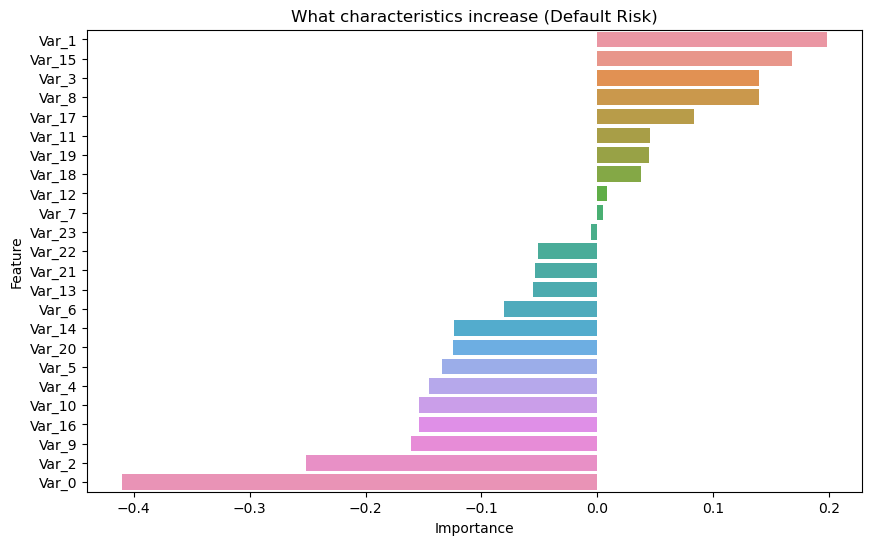

In [3]:
# We create a table with the coefficients (Coefficients)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_scoring.coef_[0]
}).sort_values(by='Importance', ascending=False)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('What characteristics increase (Default Risk)')
plt.show()

In [4]:
def scaling_score(probability, pdo=20, base_score=600, base_odds=50):
    # Calculation of Factor and Offset
    factor = pdo / np.log(2)
    offset = base_score - factor * np.log(base_odds)
    
    # Convert probability to Odds
    # We add a minimum epsilon to avoid division by zero
    odds = (1 - probability) / (probability + 1e-10)
    
    # Final Score
    score = offset + factor * np.log(odds)
    return score

#  We get the probabilities (Probability of Default) from our model
probs = model_scoring.predict_proba(X_test_scaled)[:, 1]

#  We apply the function to the entire test set
test_scores = [scaling_score(p) for p in probs]

#  We create a DataFrame to see them clearly
results_df = pd.DataFrame({
    'Actual_Status': y_test.values, # 0=Good, 1=Bad
    'PD': probs,                   # Possibility of Failure to Pay
    'Credit_Score': test_scores
})

# We limit the score to the range 300-850
results_df['Credit_Score'] = results_df['Credit_Score'].clip(300, 850).astype(int)

print("Credit Scores calculated!")
results_df.head(10)

Credit Scores calculated!


,Actual_Status,PD,Credit_Score
0,1,0.631571,471
1,0,0.667861,466
2,0,0.817896,443
3,0,0.469483,490
4,0,0.251588,518
5,0,0.604564,474
6,0,0.302596,511
7,0,0.492442,487
8,0,0.279945,514
9,0,0.299450,511


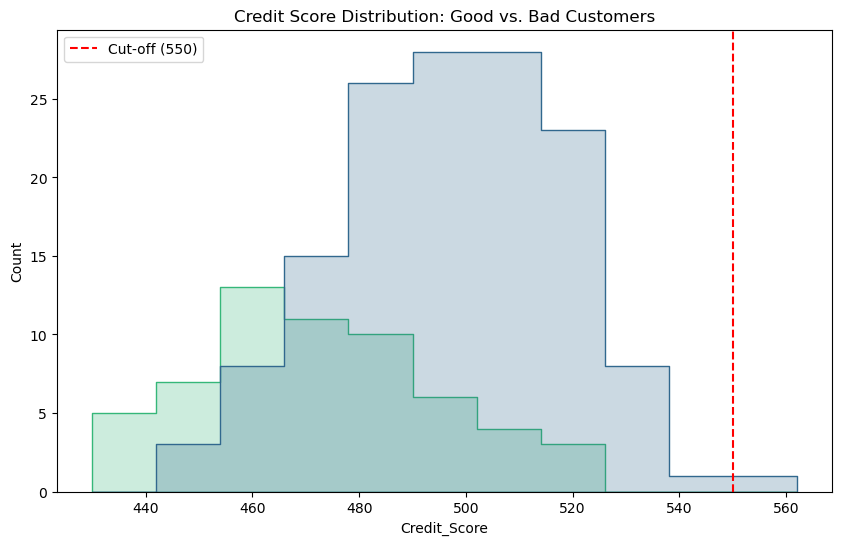

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data=results_df, x='Credit_Score', hue='Actual_Status', element='step', palette='viridis')
plt.axvline(x=550, color='red', linestyle='--', label='Cut-off (550)')
plt.title('Credit Score Distribution: Good vs. Bad Customers')
plt.legend()
plt.show()

In [6]:
# Manual test with "very bad" values (negative after scaling)
fake_bad_scaled = np.full((1, 24), -2.0) # All features at nadir
risky_pd = model_scoring.predict_proba(fake_bad_scaled)[:, 1][0]
risky_score = int(np.clip(scaling_score(risky_pd), 300, 850))

print(f"PD: {risky_pd:.2%}, Score: {risky_score}")

PD: 87.53%, Score: 430


📊 Cross-Validation ROC-AUC Scores: [0.83857327 0.74944196 0.72209821 0.85900298 0.80357143]
✅ Average Performance: 79.45%
📉 Fluctuation (Stability): 0.0519


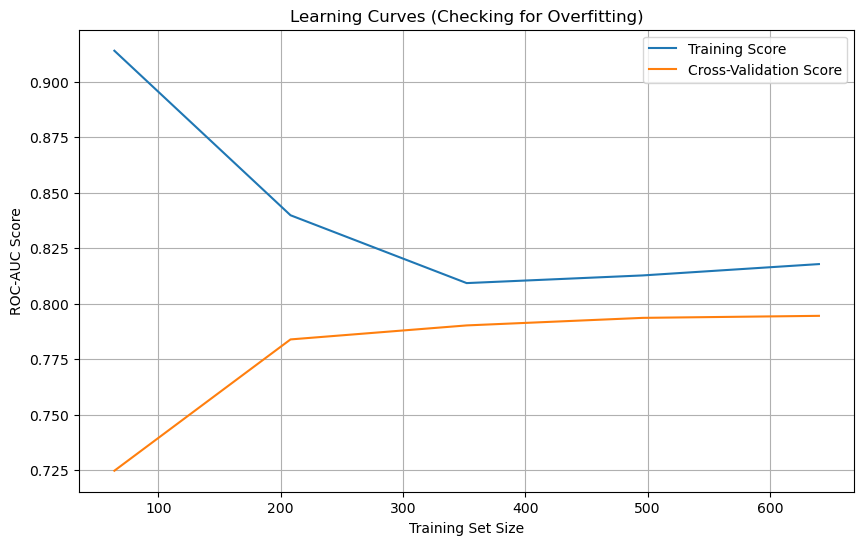

In [7]:
# Cross-Validation (5-Fold)
# We check the accuracy in 5 different parts of the data
cv_scores = cross_val_score(model_scoring, X_train_scaled, y_train, cv=5, scoring='roc_auc')

print(f"📊 Cross-Validation ROC-AUC Scores: {cv_scores}")
print(f"✅ Average Performance: {cv_scores.mean():.2%}")
print(f"📉 Fluctuation (Stability): {cv_scores.std():.4f}")

# Learning Curves
train_sizes, train_scores, test_scores = learning_curve(
    model_scoring, X_train_scaled, y_train, cv=5, scoring='roc_auc', n_jobs=-1
)

# Calculation of averages
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Score')
plt.plot(train_sizes, test_mean, label='Cross-Validation Score')
plt.title('Learning Curves (Checking for Overfitting)')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC Score')
plt.legend()
plt.grid(True)
plt.show()

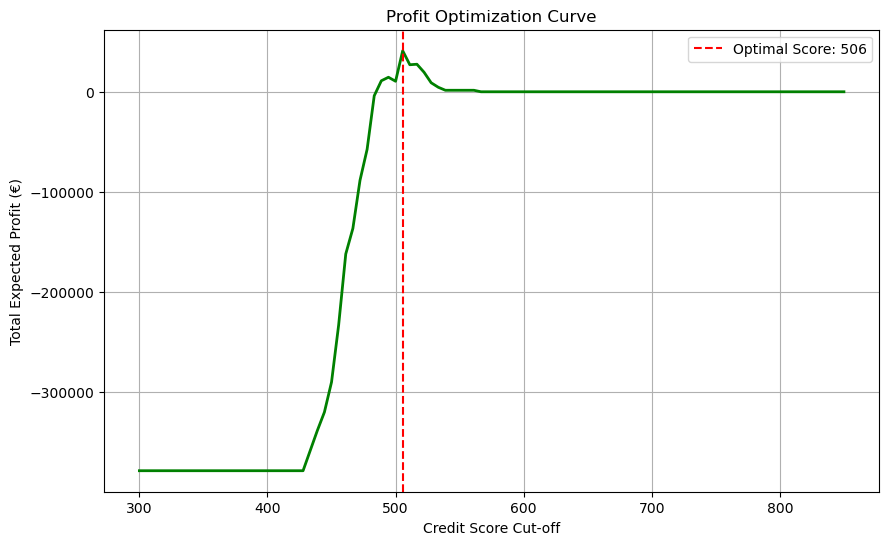

💰 The optimal Score for maximum profit is: 506
📈 Maximum expected profit: 41,000.00 €


In [8]:
#  Profit/Loss Parameters (Business Logic)
profit_per_good_loan = 1500  # Interest we earn from a "good" customer
loss_per_bad_loan = 10000    # Loss if the customer does not pay (Default)

#  Profit Calculation for Each Possible Cut-off Score
thresholds = np.linspace(300, 850, 100)
profits = []

for t in thresholds:
    # Who is approved with this threshold?
    approved = results_df[results_df['Credit_Score'] >= t]
    
    # How many of them were actually good (True Negatives) and how many were bad (False Negatives)?
    # Note: Actual_Status 0 = Good, 1 = Bad
    true_negatives = len(approved[approved['Actual_Status'] == 0])
    false_negatives = len(approved[approved['Actual_Status'] == 1])
    
    # Total Profit
    total_profit = (true_negatives * profit_per_good_loan) - (false_negatives * loss_per_bad_loan)
    profits.append(total_profit)

# Finding the Optimal Threshold
optimal_threshold = thresholds[np.argmax(profits)]
max_profit = max(profits)

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(thresholds, profits, color='green', lw=2)
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal Score: {optimal_threshold:.0f}')
plt.title('Profit Optimization Curve')
plt.xlabel('Credit Score Cut-off')
plt.ylabel('Total Expected Profit (€)')
plt.legend()
plt.grid(True)
plt.show()

print(f"💰 The optimal Score for maximum profit is: {optimal_threshold:.0f}")
print(f"📈 Maximum expected profit: {max_profit:,.2f} €")

In [9]:
# Calculating probabilities for the Training Set
train_probs = model_scoring.predict_proba(X_train_scaled)[:, 1]

# Conversion to Credit Scores (300-850)
y_train_scores = np.array([scaling_score(p) for p in train_probs]).clip(300, 850)
y_test_scores = np.array(results_df['Credit_Score'])

In [10]:
def calculate_psi(expected, actual, buckets=10):
    def scale_range(input_data):
        return np.histogram(input_data, bins=buckets, range=(300, 850))[0] / len(input_data)
    
    expected_percents = scale_range(expected)
    actual_percents = scale_range(actual)
    
    # Avoid division by zero
    actual_percents = np.where(actual_percents == 0, 0.0001, actual_percents)
    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    
    psi_values = (expected_percents - actual_percents) * np.log(expected_percents / actual_percents)
    return np.sum(psi_values)


final_psi = calculate_psi(y_train_scores, y_test_scores)

print(f"📊 Population Stability Index (PSI): {final_psi:.4f}")

if final_psi < 0.1:
    print("✅ The model is extremely stable.")
elif final_psi < 0.25:
    print("⚠️ There is a minor shift in the population.")
else:
    print("🚨 SOS: The model needs retraining!")

📊 Population Stability Index (PSI): 0.0101
✅ The model is extremely stable.


In [11]:
results_df['Optimal_Threshold'] = optimal_threshold
results_df['Max_Expected_Profit'] = max_profit
results_df['PSI_Score'] = final_psi

In [12]:
# Export the results for Power BI
results_df.to_csv('credit_scoring_results.csv', index=False)
print("✅ CSV updated with PSI and Profit Metrics! Click Refresh in Power BI.")

✅ CSV updated with PSI and Profit Metrics! Click Refresh in Power BI.
